In [1]:
import codecs
import os
import re
import pymorphy2

In [13]:
def lemmatize_text(text):
    """
    Лемматизирует текст на русском языке
    """
    morph = pymorphy2.MorphAnalyzer()

    text = re.sub(r'[^\w\s]', ' ', text.lower())
    
    words = text.split()
    lemmatized_words = []
    
    for word in words:
        if word.strip():  
            parsed_word = morph.parse(word)[0]
            lemma = parsed_word.normal_form
            lemmatized_words.append(lemma)
    
    return ' '.join(lemmatized_words)

In [15]:
def process_files(input_folder, output_folder):
    """
    Обрабатывает все .txt файлы в папке input_folder и сохраняет лемматизированные версии в output_folder
    """
    # Создаем выходную папку, если её нет
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Обрабатываем каждый файл
    for filename in os.listdir(input_folder):
        if filename.endswith('.txt'):
            input_path = os.path.join(input_folder, filename)
            output_path = os.path.join(output_folder, f'lemmatized_{filename}')
            
            # Читаем файл
            with codecs.open(input_path, 'r') as f:
                text = f.read()
            
            # Лемматизируем текст
            lemmatized_text = lemmatize_text(text)
            
            # Сохраняем результат
            with codecs.open(output_path, 'w') as f:
                f.write(lemmatized_text)
            
            print(f'Обработан файл: {filename}')

In [16]:
input_folder = 'C:/Users/user/Documents/GitHub/MSP/TM/100great_raw'
output_folder = 'C:/Users/user/Documents/GitHub/MSP/TM/100great_lemmatized'

print('Начинаем лемматизацию файлов...')
process_files(input_folder, output_folder)
print('Лемматизация завершена!')

Начинаем лемматизацию файлов...
Обработан файл: 100admirals.txt
Обработан файл: 100archeology.txt
Обработан файл: 100architects.txt
Обработан файл: 100aristocrats.txt
Обработан файл: 100artists.txt
Обработан файл: 100awards.txt
Обработан файл: 100cities.txt
Обработан файл: 100genius.txt
Обработан файл: 100gods.txt
Обработан файл: 100heroes.txt
Обработан файл: 100inventions.txt
Обработан файл: 100militsecr.txt
Обработан файл: 100naturemist.txt
Обработан файл: 100nobel.txt
Обработан файл: 100painters.txt
Обработан файл: 100pictures.txt
Обработан файл: 100rebellions.txt
Обработан файл: 100sovfilms.txt
Обработан файл: 100tehnika.txt
Обработан файл: 100treasures.txt
Обработан файл: 100vocalists.txt
Обработан файл: 100women.txt
Лемматизация завершена!


In [2]:
from sklearn.decomposition import LatentDirichletAllocation

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

In [5]:
PATH = 'C:/Users/user/Documents/GitHub/MSP/TM/100great_lemmatized'
NUM_TOPICS = 10
N_FIRST = 20 # сколько первых слов на тему выводить
MIN_DF = 5 # минимальное число вхождений слова в документ, чтобы мы его учитывали (включали в вектор документа)
MAX_DF = 0.90 # в каком проценте документов должно присутствовать слово, чтобы оно не рассматривалось
STW_PATH = 'C:/Users/user/Documents/GitHub/MSP/TM/swl.txt' # путь к документу со стоп-словами

In [6]:
with codecs.open(STW_PATH, encoding = 'utf-8') as f:
     stw_list = f.read().split()[1:]

In [7]:
file_names = os.listdir(PATH)
data = []
for name in file_names:
    if name.endswith(".txt"):
        with codecs.open(PATH + "/" + name) as f:
            data.append(f.read())

In [8]:
count_vectorizer = CountVectorizer(min_df=MIN_DF, max_df=MAX_DF, stop_words = stw_list)
data_count_vectorized = count_vectorizer.fit_transform(data)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ак', 'бляха', 'богу', 'бу', 'буль', 'вашему', 'вообще', 'всякому', 'го', 'другому', 'ей', 'елки', 'иному', 'кей', 'кис', 'кэй', 'ля', 'мое', 'моему', 'муха', 'нашему', 'нить', 'палки', 'паф', 'пиф', 'пли', 'своему', 'твоему', 'тик', 'тра', 'тс', 'ту', 'чегой', 'черт', 'чик', 'чтой', 'яй'] not in stop_words.
  warnings.warn(


In [10]:
lda_model = LatentDirichletAllocation(n_components=NUM_TOPICS, max_iter=20, learning_method='batch', batch_size=512, random_state = 2)
lda_model.fit_transform(data_count_vectorized);

In [11]:
def print_topics(model, vectorizer, top_n=10):
    all_topics = []
    for idx, topic in enumerate(model.components_):
        print("Topic %d:" % (idx))
        all_topics.append([(vectorizer.get_feature_names_out()[i], topic[i])
                        for i in topic.argsort()[:-top_n - 1:-1]])
        print([(vectorizer.get_feature_names_out()[i], topic[i])
                        for i in topic.argsort()[:-top_n - 1:-1]])
    return all_topics

In [12]:
print_topics(lda_model, count_vectorizer)

Topic 0:
[('вежливость', 0.10000000102740332), ('издёвка', 0.10000000076771032), ('туманов', 0.10000000068881078), ('наперёд', 0.10000000036215911), ('пессимистический', 0.10000000032153698), ('согласованно', 0.10000000029016981), ('поручиться', 0.10000000028856214), ('осчастливить', 0.1000000002604051), ('правдоподобно', 0.10000000019844628), ('отождествляться', 0.10000000018392385)]
Topic 1:
[('вежливость', 0.10000000102740332), ('издёвка', 0.10000000076771032), ('туманов', 0.10000000068881078), ('наперёд', 0.10000000036215911), ('пессимистический', 0.10000000032153698), ('согласованно', 0.10000000029016981), ('поручиться', 0.10000000028856214), ('осчастливить', 0.1000000002604051), ('правдоподобно', 0.10000000019844628), ('отождествляться', 0.10000000018392385)]
Topic 2:
[('археолог', 609.7429283163773), ('раскопка', 532.9317393190629), ('богиня', 492.74387522739977), ('племя', 442.723830326426), ('статуя', 433.1502677484365), ('гробница', 431.1684293276045), ('пирамида', 413.772583

[[('вежливость', 0.10000000102740332),
  ('издёвка', 0.10000000076771032),
  ('туманов', 0.10000000068881078),
  ('наперёд', 0.10000000036215911),
  ('пессимистический', 0.10000000032153698),
  ('согласованно', 0.10000000029016981),
  ('поручиться', 0.10000000028856214),
  ('осчастливить', 0.1000000002604051),
  ('правдоподобно', 0.10000000019844628),
  ('отождествляться', 0.10000000018392385)],
 [('вежливость', 0.10000000102740332),
  ('издёвка', 0.10000000076771032),
  ('туманов', 0.10000000068881078),
  ('наперёд', 0.10000000036215911),
  ('пессимистический', 0.10000000032153698),
  ('согласованно', 0.10000000029016981),
  ('поручиться', 0.10000000028856214),
  ('осчастливить', 0.1000000002604051),
  ('правдоподобно', 0.10000000019844628),
  ('отождествляться', 0.10000000018392385)],
 [('археолог', 609.7429283163773),
  ('раскопка', 532.9317393190629),
  ('богиня', 492.74387522739977),
  ('племя', 442.723830326426),
  ('статуя', 433.1502677484365),
  ('гробница', 431.1684293276045),

In [13]:
all_topics = print_topics(lda_model, count_vectorizer)

for i,topic in enumerate(all_topics):
    print("-------------------------------")
    print("Тема ",i)
    for pair in topic:
        print(pair[0])

Topic 0:
[('вежливость', 0.10000000102740332), ('издёвка', 0.10000000076771032), ('туманов', 0.10000000068881078), ('наперёд', 0.10000000036215911), ('пессимистический', 0.10000000032153698), ('согласованно', 0.10000000029016981), ('поручиться', 0.10000000028856214), ('осчастливить', 0.1000000002604051), ('правдоподобно', 0.10000000019844628), ('отождествляться', 0.10000000018392385)]
Topic 1:
[('вежливость', 0.10000000102740332), ('издёвка', 0.10000000076771032), ('туманов', 0.10000000068881078), ('наперёд', 0.10000000036215911), ('пессимистический', 0.10000000032153698), ('согласованно', 0.10000000029016981), ('поручиться', 0.10000000028856214), ('осчастливить', 0.1000000002604051), ('правдоподобно', 0.10000000019844628), ('отождествляться', 0.10000000018392385)]
Topic 2:
[('археолог', 609.7429283163773), ('раскопка', 532.9317393190629), ('богиня', 492.74387522739977), ('племя', 442.723830326426), ('статуя', 433.1502677484365), ('гробница', 431.1684293276045), ('пирамида', 413.772583

In [31]:
!pip install pyLDAvis

In [14]:
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda_model, data_count_vectorized, count_vectorizer, mds='tsne')
panel

PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
9      68.106773 -60.973412       1        1  20.143337
2      32.983040 -12.873476       2        1  17.246755
5     -74.659279  10.313410       3        1  16.998336
4      -9.981817  25.476791       4        1  16.418525
3      85.281097  15.616014       5        1  13.825862
6     -70.629723 -63.134548       6        1   8.242277
7     -40.087414  75.478767       7        1   7.124072
0     -21.821581 -30.761114       8        1   0.000279
1      37.126366  64.576057       9        1   0.000279
8       4.297317 -85.858620      10        1   0.000279, topic_info=                Term         Freq        Total Category  logprob  loglift
16727          фильм  3227.000000  3227.000000  Default  30.0000  30.0000
793          адмирал  1487.000000  1487.000000  Default  29.0000  29.0000
853            актёр  1913.000000  1913.000000  Default  28.0000  28.0000
1133     архитектура  1222.000000  1222.000000  Default  27.0000  27.0000
1132      архитектор  1039.000000  1039.000000  Default  26.0000  26.0000
...              ...          ...          ...      ...      ...      ...
14737     совмещение     0.000123     8.574941  Topic10  -9.7904   1.6383
8798   непосвящённый     0.000123    14.475858  Topic10  -9.7904   1.1146
2583     возмутиться     0.000123    18.558684  Topic10  -9.7904   0.8662
13489    расчленение     0.000123    12.460861  Topic10  -9.7904   1.2645
12651   промахнуться     0.000123     6.658464  Topic10  -9.7904   1.8912

[681 rows x 6 columns], token_table=       Topic      Freq      Term
term                            
720        1  0.167454  авангард
720        4  0.027909  авангард
720        5  0.013954  авангард
720        6  0.767496  авангард
720        7  0.018606  авангард
...      ...       ...       ...
17833      3  0.025907    японец
17833      4  0.025907    японец
17833      5  0.038860    японец
17833      6  0.764252    японец
17833      7  0.017271    японец

[1777 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[10, 3, 6, 5, 4, 7, 8, 1, 2, 9])

In [15]:
lda_model.perplexity(data_count_vectorized)

6332.5867676234475

In [16]:
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt

In [17]:
# Загрузка лемматизированных текстов
lemmatized_texts = []
lemmatized_dir = '100great_lemmatized'

for filename in os.listdir(lemmatized_dir):
    if filename.startswith('lemmatized_'):
        with codecs.open(os.path.join(lemmatized_dir, filename), 'r') as f:
            lemmatized_texts.append(f.read())

In [18]:
data_tokenized = [doc.split() for doc in lemmatized_texts]  

dictionary = corpora.Dictionary(data_tokenized)
corpus = [dictionary.doc2bow(text) for text in data_tokenized]

In [22]:
def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = LdaModel(corpus=corpus,
                         id2word=dictionary,
                         num_topics=num_topics)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
    return model_list, coherence_values

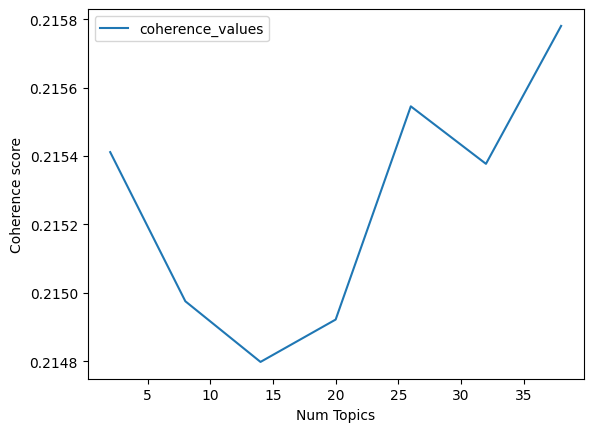

In [ ]:
start, limit, step = 2, 40, 6
model_list, coherence_values = compute_coherence_values(
    dictionary=dictionary, 
    corpus=corpus, 
    texts=data_tokenized, 
    start=start, 
    limit=limit, 
    step=step
)

x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values",), loc='best')
plt.show()